In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score
import joblib

In [2]:
df = pd.read_csv('dataset\Crop_recommendationV2.csv')
df.head()

<>:1: SyntaxWarning: "\C" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\C"? A raw string is also an option.
<>:1: SyntaxWarning: "\C" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\C"? A raw string is also an option.
C:\Users\KAVYA\AppData\Local\Temp\ipykernel_16180\2751180288.py:1: SyntaxWarning: "\C" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\C"? A raw string is also an option.
  df = pd.read_csv('dataset\Crop_recommendationV2.csv')


,N,P,K,temperature,humidity,ph,rainfall,label,soil_moisture,soil_type,...,organic_matter,irrigation_frequency,crop_density,pest_pressure,fertilizer_usage,growth_stage,urban_area_proximity,water_source_type,frost_risk,water_usage_efficiency
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice,29.446064,2,...,3.121395,4,11.743910,57.607308,188.194958,1,2.719614,3,95.649985,1.193293
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice,12.851183,3,...,2.142021,4,16.797101,74.736879,70.963629,1,4.714427,2,77.265694,1.752672
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice,29.363913,2,...,1.474974,1,12.654395,1.034478,191.976077,1,30.431736,2,18.192168,3.035541
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice,26.207732,3,...,8.393907,1,10.864360,24.091888,55.761388,3,10.861071,3,82.818720,1.273341
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice,28.236236,2,...,5.202285,3,13.852910,38.811481,185.259702,2,47.190777,3,25.466499,2.578671


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 23 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   N                       2200 non-null   int64  
 1   P                       2200 non-null   int64  
 2   K                       2200 non-null   int64  
 3   temperature             2200 non-null   float64
 4   humidity                2200 non-null   float64
 5   ph                      2200 non-null   float64
 6   rainfall                2200 non-null   float64
 7   label                   2200 non-null   str    
 8   soil_moisture           2200 non-null   float64
 9   soil_type               2200 non-null   int64  
 10  sunlight_exposure       2200 non-null   float64
 11  wind_speed              2200 non-null   float64
 12  co2_concentration       2200 non-null   float64
 13  organic_matter          2200 non-null   float64
 14  irrigation_frequency    2200 non-null   int64  
 15

In [4]:
df.describe()

,N,P,K,temperature,humidity,ph,rainfall,soil_moisture,soil_type,sunlight_exposure,...,organic_matter,irrigation_frequency,crop_density,pest_pressure,fertilizer_usage,growth_stage,urban_area_proximity,water_source_type,frost_risk,water_usage_efficiency
count,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,...,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000
mean,50.551818,53.362727,48.149091,25.616244,71.481779,6.469480,103.463655,20.151388,1.991364,8.570609,...,5.465652,3.515000,12.344959,49.850701,125.846403,1.999545,24.801013,2.003636,50.304701,2.990268
std,36.917334,32.985883,50.647931,5.063749,22.263812,0.773938,54.958389,5.793720,0.812263,1.999382,...,2.605294,1.697912,4.297494,28.886354,43.564527,0.818999,14.523975,0.812021,28.580352,1.139637
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,20.211267,10.024260,1.000000,5.000710,...,1.003338,1.000000,5.004341,0.038103,50.209990,1.000000,0.017756,1.000000,0.054911,1.002106
25%,21.000000,28.000000,20.000000,22.769375,60.261953,5.971693,64.551686,15.179949,1.000000,6.904620,...,3.203903,2.000000,8.585734,24.379866,88.030737,1.000000,12.212594,1.000000,26.104674,2.051814
50%,37.000000,51.000000,32.000000,25.598693,80.473146,6.425045,94.867624,20.088481,2.000000,8.609968,...,5.418049,4.000000,12.303616,49.982421,126.441536,2.000000,24.922548,2.000000,50.171934,2.968675
75%,84.250000,68.000000,49.000000,28.561654,89.948771,6.923643,124.267508,25.255146,3.000000,10.220394,...,7.686417,5.000000,15.975567,74.681904,163.850536,3.000000,37.322761,3.000000,75.262676,3.968736
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091,298.560117,29.997860,3.000000,11.991041,...,9.999990,6.000000,19.988474,99.983849,199.982166,3.000000,49.992046,3.000000,99.957274,4.997130


In [5]:
df['label'].unique()

<StringArray>
[       'rice',       'maize',    'chickpea', 'kidneybeans',  'pigeonpeas',
   'mothbeans',    'mungbean',   'blackgram',      'lentil', 'pomegranate',
      'banana',       'mango',      'grapes',  'watermelon',   'muskmelon',
       'apple',      'orange',      'papaya',     'coconut',      'cotton',
        'jute',      'coffee']
Length: 22, dtype: str

In [6]:
groups = {
    'rice': 'wetland',
    'maize': 'cereal', 'jute': 'cereal', 'cotton': 'cereal', 'coffee': 'cereal',
    'chickpea': 'legume', 'kidneybeans': 'legume', 'pigeonpeas': 'legume', 
    'mothbeans': 'legume', 'mungbean': 'legume', 'blackgram': 'legume', 'lentil': 'legume',
    'banana': 'tropical', 'papaya': 'tropical', 'coconut': 'tropical',
    'pomegranate': 'orchard', 'mango': 'orchard', 'grapes': 'orchard', 
    'watermelon': 'orchard', 'muskmelon': 'orchard', 'apple': 'orchard', 'orange': 'orchard'
}

df['crop_type'] = df['label'].str.lower().str.strip().map(groups)

In [7]:
kc_map = {
    'wetland':  {1: 1.05, 2: 1.15, 3: 1.20, 4: 0.90},
    'cereal':   {1: 0.30, 2: 0.75, 3: 1.15, 4: 0.60},
    'legume':   {1: 0.40, 2: 0.80, 3: 1.10, 4: 0.45},
    'tropical': {1: 0.70, 2: 0.90, 3: 1.10, 4: 0.95},
    'orchard':  {1: 0.50, 2: 0.75, 3: 0.95, 4: 0.70}
}

In [8]:
df['growth_stage'] = df['growth_stage'].astype(float) + np.random.uniform(-0.2, 0.2, size=len(df))
df['growth_stage'] = df['growth_stage'].clip(1, 4)

In [9]:
sensor_cols = ['temperature', 'humidity', 'rainfall', 'soil_moisture', 'sunlight_exposure', 'wind_speed']
for col in sensor_cols:
    if col in df.columns:
        df[col] = df[col].astype(float) + np.random.uniform(-0.5, 0.5, size=len(df))


In [10]:
df['rainfall'] = df['rainfall'] / 10 
df['soil_moisture'] = df['soil_moisture'].clip(10, 45)

In [11]:
df[['rainfall','soil_moisture']].describe()

,rainfall,soil_moisture
count,2200.000000,2200.000000
mean,10.346232,20.154860
std,5.496070,5.803414
min,2.027339,10.000000
25%,6.458497,15.278199
50%,9.486315,20.084071
75%,12.416965,25.245570
max,29.807260,30.494029


In [12]:
def calculate_irrigation(row):
    eto = (row['temperature'] * 0.18) + (row['sunlight_exposure'] * 0.12) - (row['humidity'] * 0.02)    
    
    crop_name = str(row['label']).lower().strip()
    group = groups.get(crop_name, 'cereal') 
    stage = int(row['growth_stage'])
    kc = kc_map[group].get(stage, 0.8)
    
    etc = eto * kc
    
    target_moisture = 80 if group == 'wetland' else 55
    current_moisture = row['soil_moisture']
    deficit_correction = max(0, target_moisture - current_moisture) * 0.35

    pe = row['rainfall'] * 0.5

    total_mm = etc + deficit_correction - pe
    
    return round(max(0, total_mm), 2)

df['target_irrigation_mm'] = df.apply(calculate_irrigation, axis=1)
print(f"Total rows processed: {len(df)}")
print(f"New Unique target values: {df['target_irrigation_mm'].nunique()}")

Total rows processed: 2200
New Unique target values: 1064


In [13]:
df['target_irrigation_mm'].describe()

count    2200.000000
mean       10.332473
std         3.347297
min         0.000000
25%         8.007500
50%        10.395000
75%        12.780000
max        19.590000
Name: target_irrigation_mm, dtype: float64

In [14]:
df['target_irrigation_mm'].unique()

array([10.81, 15.24,  8.48, ...,  1.39,  5.99,  1.71], shape=(1064,))

In [15]:
df[['crop_type','target_irrigation_mm','growth_stage']].head(10)

,crop_type,target_irrigation_mm,growth_stage
0,wetland,10.81,1.168612
1,wetland,15.24,1.151867
2,wetland,8.48,1.000000
3,wetland,11.52,2.962526
4,wetland,8.31,1.948773
5,wetland,11.85,3.058249
6,wetland,12.68,1.022272
7,wetland,12.22,1.000000
8,wetland,11.89,2.921365
9,wetland,11.70,1.000000


In [16]:
le_crop = LabelEncoder()
le_type = LabelEncoder()

df['crop_encoded'] = le_crop.fit_transform(df['label'])
df['type_encoded'] = le_type.fit_transform(df['crop_type'])

In [17]:
features = [
    'temperature', 'humidity', 'rainfall', 'soil_moisture', 
    'sunlight_exposure', 'wind_speed', 'growth_stage', 
    'type_encoded', 'crop_encoded'
]

X = df[features]
y = df['target_irrigation_mm']

print("--- Encoding Complete ---")
print(f"Total Features: {len(features)}")
print(f"Encoded Categories: {list(le_type.classes_)}")

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

--- Encoding Complete ---
Total Features: 9
Encoded Categories: ['cereal', 'legume', 'orchard', 'tropical', 'wetland']


In [18]:
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [19]:
y_pred = model.predict(X_test)
r2 = model.score(X_test, y_test)
print(f"--- Phase 1 Complete ---")
print(f"Model R2 Score: {r2:.4f}")
print(f"Files saved: irrigation_model.pkl and crop_encoder.pkl")

--- Phase 1 Complete ---
Model R2 Score: 0.9675
Files saved: irrigation_model.pkl and crop_encoder.pkl


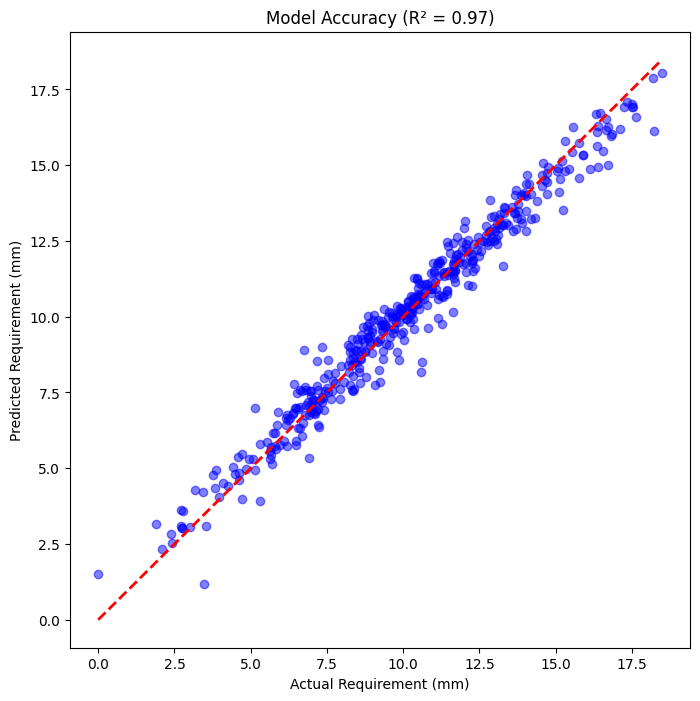

In [20]:
plt.figure(figsize=(8, 8))
plt.scatter(y_test, y_pred, alpha=0.5, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2) # 45-degree line
plt.xlabel('Actual Requirement (mm)')
plt.ylabel('Predicted Requirement (mm)')
plt.title(f'Model Accuracy (R² = {r2_score(y_test, y_pred):.2f})')
plt.show()

RuntimeError: `lowess=True` requires statsmodels, an optional dependency, to be installed.

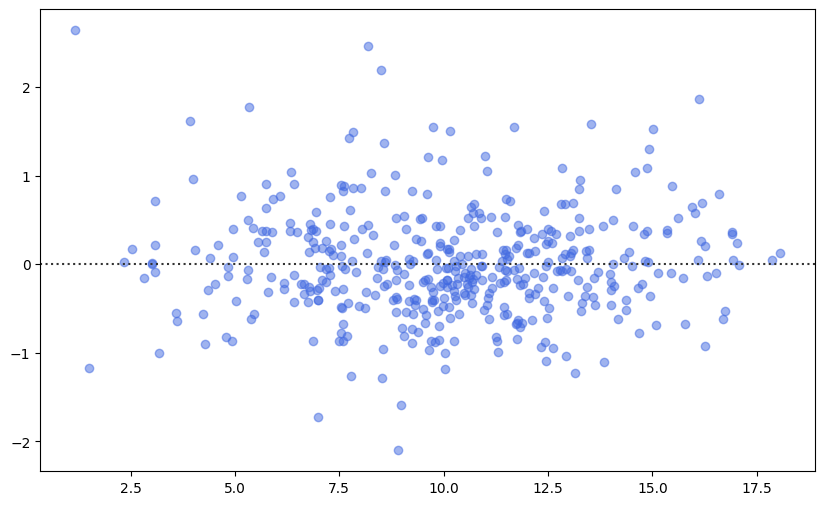

In [21]:
residuals = y_test - y_pred


plt.figure(figsize=(10, 6))
sns.residplot(x=y_pred, y=residuals, lowess=True, 
              scatter_kws={'alpha': 0.5, 'color': 'royalblue'},
              line_kws={'color': 'red', 'lw': 2})


plt.axhline(0, color='black', linestyle='--') 
plt.xlabel('Predicted Irrigation (mm)', fontsize=12)
plt.ylabel('Residuals (Error Value)', fontsize=12)
plt.title('Residual Analysis: Evaluating Error Distribution', fontsize=14)
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

In [ ]:
joblib.dump(model, 'irrigation_model.pkl')

['irrigation_model.pkl']

In [ ]:
joblib.dump(le_crop, 'crop_encoder.pkl')

['crop_encoder.pkl']

In [ ]:
joblib.dump(le_type, 'type_encoder.pkl')

['type_encoder.pkl']

In [22]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Assuming y_test and y_pred are already defined in your code
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"MAE: {mae}, RMSE: {rmse}")

MAE: 0.4642152272727277, RMSE: 0.6156844366047213


In [40]:
def get_binary_irrigation_class(value):
    # Threshold set at 4.0mm based on your mean rainfall
    if value <= 4.0:
        return 0 # No Irrigation
    else:
        return 1 # Irrigation Required

# Apply the binary mapping
y_test_binary = [get_binary_irrigation_class(val) for val in y_test]
y_pred_binary = [get_binary_irrigation_class(val) for val in y_pred]

# Generate binary metrics
print(classification_report(y_test_binary, y_pred_binary, target_names=['No Irrig', 'Irrig']))

              precision    recall  f1-score   support

    No Irrig       0.87      0.68      0.76        19
       Irrig       0.99      1.00      0.99       421

    accuracy                           0.98       440
   macro avg       0.93      0.84      0.88       440
weighted avg       0.98      0.98      0.98       440

